# Practical Growth Assessment Workflow

This notebook shows how the Feature Engineering and Time Series work can be used in a small practical workflow.

The goal is not to create a veterinary product. The goal is to demonstrate that the mathematical features can be applied to new Cane Corso measurements and turned into a readable educational report.


In [ ]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Project root not found. Open this notebook from the project folder or adjust the working directory.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook ready. Project root: {PROJECT_ROOT}")


## Mathematical Idea

A repeated measurement can be represented as:

```text
r(t) = [age_months(t), weight_kg(t), height_cm(t)]
```

The practical workflow uses:

```text
weight_gain(t) = weight(t) - weight(t-1)
growth_velocity(t) = weight_gain(t) / delta_age(t)
z = (latest_velocity - reference_mean_velocity) / reference_standard_deviation
distance = sqrt(sum((x_latest_scaled - x_reference_scaled)^2))
```

This is a learning workflow: formulas first, then code, then interpretation.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Markdown, Image, display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent

sys.path.insert(0, str(project_root))
project_root


PosixPath('/mnt/data/ccgi_step101')

## Load the Example Input

The input file behaves like a small owner record: one dog, repeated measurements over time.


In [2]:
input_path = project_root / 'data' / 'input' / 'example_new_cane_corso_measurements.csv'
measurements = pd.read_csv(input_path)
measurements


,dog_id,dog_name,sex,age_months,weight_kg,height_cm,activity_level,source_type
0,101,Ares Practical Example,male,2,8.5,31,medium,user_example
1,101,Ares Practical Example,male,4,17.8,40,medium,user_example
2,101,Ares Practical Example,male,6,28.5,49,medium,user_example
3,101,Ares Practical Example,male,8,38.7,57,medium,user_example
4,101,Ares Practical Example,male,10,46.2,62,medium,user_example
5,101,Ares Practical Example,male,12,51.8,66,medium,user_example


## Run the Practical Workflow

The script engineers features, compares the latest record with the reference feature dataset, creates figures and writes a report.


In [3]:
from src.run_growth_assessment import run_assessment

result = run_assessment()
assessment = result['assessment']

print('Practical signal:', assessment.practical_signal)
print('Latest velocity z-score:', round(assessment.velocity_z_score, 3))
print('Weight deviation percent:', round(assessment.weight_deviation_percent, 3))
print('Report:', result['report_path'])


Practical signal: monitoring_signal_stable_in_learning_context
Latest velocity z-score: -0.869
Weight deviation percent: 8.142
Report: /mnt/data/ccgi_step101/reports/example_growth_assessment_report.md


## Engineered Output Features

The workflow creates a processed feature dataset that can be inspected like the previous course notebooks.


In [4]:
features_path = project_root / 'data' / 'processed' / 'example_growth_assessment_features.csv'
features = pd.read_csv(features_path)
features.tail()


,dog_id,dog_name,sex,age_months,weight_kg,height_cm,activity_level,source_type,previous_age_months,previous_weight_kg,previous_height_cm,delta_age_months,weight_gain_kg,height_gain_cm,growth_velocity_kg_per_month,height_velocity_cm_per_month,weight_to_height_ratio,rolling_weight_mean_3,rolling_growth_velocity_3,growth_phase
1,101,Ares Practical Example,male,4,17.8,40,medium,user_example,2.0,8.5,31.0,2.0,9.3,9.0,4.65,4.5,0.445000,13.150000,4.650000,early_growth
2,101,Ares Practical Example,male,6,28.5,49,medium,user_example,4.0,17.8,40.0,2.0,10.7,9.0,5.35,4.5,0.581633,18.266667,5.000000,early_growth
3,101,Ares Practical Example,male,8,38.7,57,medium,user_example,6.0,28.5,49.0,2.0,10.2,8.0,5.10,4.0,0.678947,28.333333,5.033333,adolescent_growth
4,101,Ares Practical Example,male,10,46.2,62,medium,user_example,8.0,38.7,57.0,2.0,7.5,5.0,3.75,2.5,0.745161,37.800000,4.733333,adolescent_growth
5,101,Ares Practical Example,male,12,51.8,66,medium,user_example,10.0,46.2,62.0,2.0,5.6,4.0,2.80,2.0,0.784848,45.566667,3.883333,adolescent_growth


## Visual Output

The figures make the report easier to interpret.


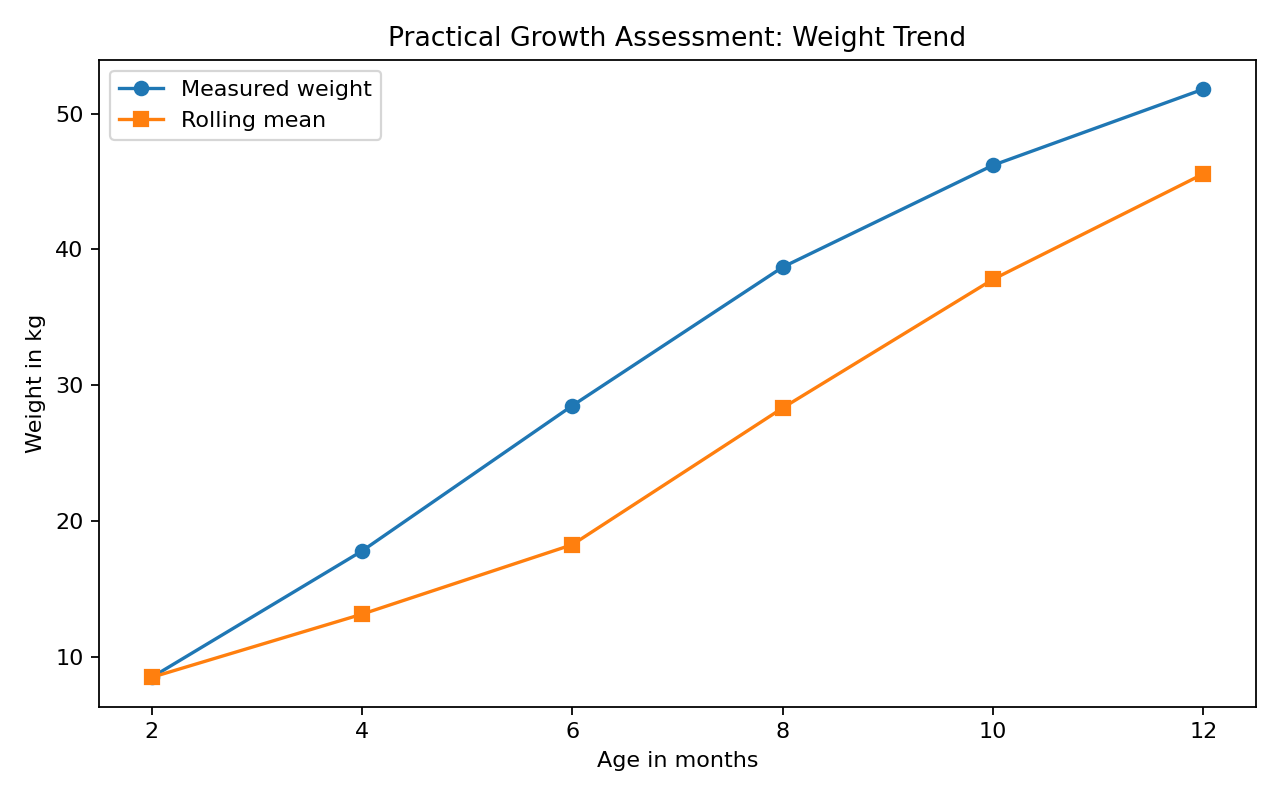

In [5]:
display(Image(filename=str(project_root / 'reports' / 'figures' / 'practical_growth_assessment_weight_trend.png')))


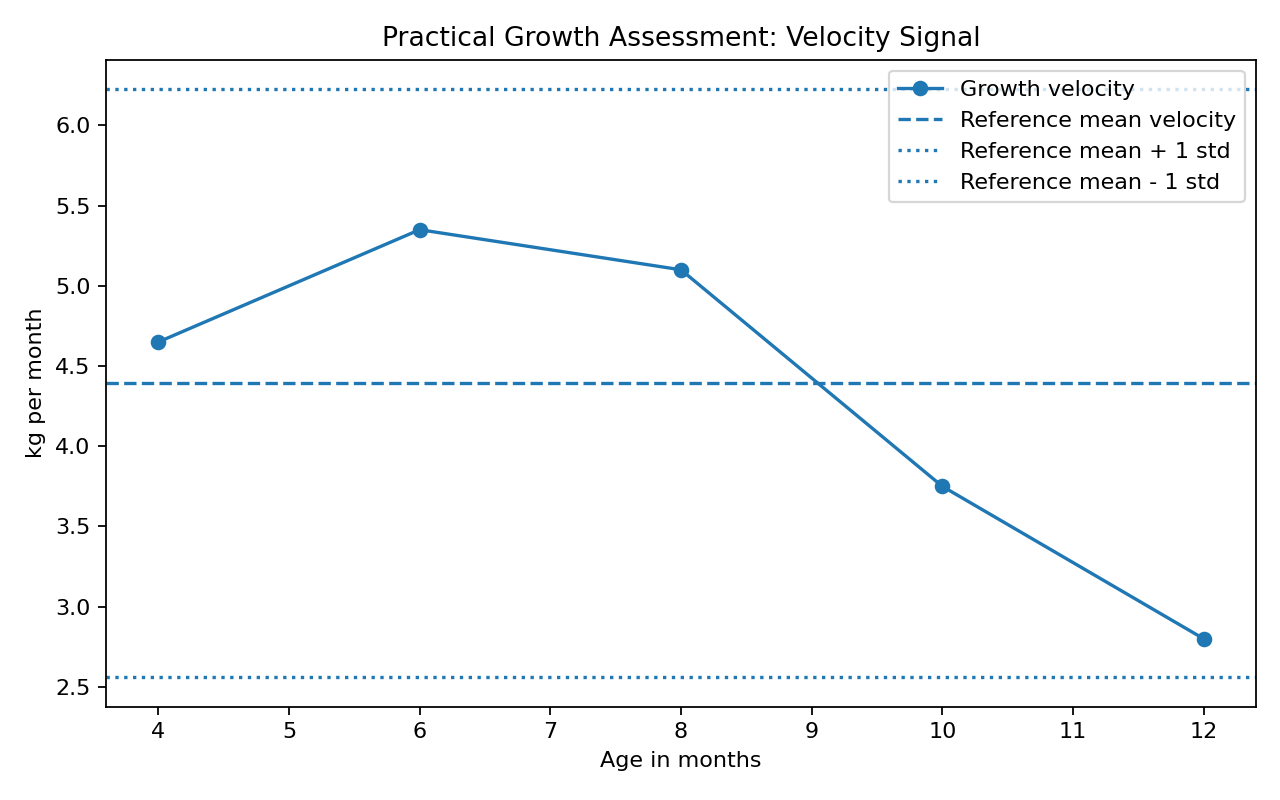

In [6]:
display(Image(filename=str(project_root / 'reports' / 'figures' / 'practical_growth_assessment_velocity_signal.png')))


## Generated Report

The markdown report is the practical output. It combines formulas, values, interpretation and limitations.


In [7]:
report_path = project_root / 'reports' / 'example_growth_assessment_report.md'
display(Markdown(report_path.read_text(encoding='utf-8')))


# Practical Cane Corso Growth Assessment Report

This report is generated by `src/run_growth_assessment.py` from the example owner-style input file:

```text
data/input/example_new_cane_corso_measurements.csv
```

## Learning Purpose

This is a practical workflow layer for the course project. It shows how the mathematical features from the Feature Engineering and Time Series lecture can be used in a small applied pipeline:

```text
input measurements -> engineered features -> reference comparison -> readable report
```

It is intentionally educational. It is not a veterinary diagnosis, treatment recommendation, pedigree proof, or Cane Corso certification.

## Latest Measurement Summary

| Field | Value |
|---|---:|
| Dog name | Ares Practical Example |
| Latest age | 12.0 months |
| Latest weight | 51.8 kg |
| Latest height | 66.0 cm |
| Weight-to-height ratio | 0.785 |
| Growth velocity | 2.80 kg/month |
| Rolling weight mean | 45.57 kg |

## Mathematical Signals

### Growth Velocity

```text
growth_velocity(t) = (weight(t) - weight(t-1)) / (age(t) - age(t-1))
```

Latest value:

```text
2.80 kg/month
```

### Z-Score Against Reference Velocity

```text
z = (latest_velocity - reference_mean_velocity) / reference_standard_deviation
```

Values:

```text
reference_mean_velocity = 4.39
reference_standard_deviation = 1.83
z_score = -0.87
```

### Age-Based Weight Deviation

```text
weight_deviation_percent = (actual_weight - expected_weight_at_age) / expected_weight_at_age * 100
```

Values:

```text
expected_weight_at_age = 47.90 kg
weight_deviation_percent = 8.14%
```

### Normalized Similarity Distance

The latest record is also compared with reference growth records using a normalized Euclidean distance over selected engineered features:

```text
distance = sqrt(sum((x_latest_scaled - x_reference_scaled)^2))
```

Nearest profile distance:

```text
0.97
```

## Practical Educational Signal

```text
monitoring_signal_stable_in_learning_context
```

Interpretation points:

- The latest growth velocity is within one standard deviation of the reference mean.
- The latest weight is reasonably close to the nearest age-based reference records.

## Output Figures

```text
reports/figures/practical_growth_assessment_weight_trend.png
reports/figures/practical_growth_assessment_velocity_signal.png
```

## Responsible Use Boundary

This workflow can help a learner or owner organize measurements and understand growth trends. It should be used only as a learning and monitoring aid. Any real health concern, unusual growth, pain, lameness, feeding problem, or development concern should be discussed with a qualified veterinarian.


## Learning Reflection

This workflow is useful because it connects the course material to an applied use case. I am still learning the methods, so the report is intentionally careful and limited. It shows how mathematical features can organize measurements and generate monitoring signals, but it does not make medical or official claims.
